In [ ]:
🧹 Part A — Preprocessing

In [93]:
## Import Libraries & Load Raw Data

import warnings
warnings.filterwarnings("ignore")

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12})

DATA_DIR = "/Users/jemwagas/Week-2-Homework"  

customers    = pd.read_csv(os.path.join(DATA_DIR, "customers_data.csv"))
products     = pd.read_csv(os.path.join(DATA_DIR, "products_data.csv"))
transactions = pd.read_csv(os.path.join(DATA_DIR, "transactions_data.csv"))

print("Raw shapes:")
print(f"  customers    : {customers.shape}")
print(f"  products     : {products.shape}")
print(f"  transactions : {transactions.shape}")

Raw shapes:
  customers    : (100, 4)
  products     : (20, 3)
  transactions : (10000, 8)


In [19]:
## Customers: Drop Rows with Missing Company ID

cust = customers.drop_duplicates()

# Report before state
n_null_id = cust["Company_ID"].isna().sum()
print(f"Rows with null Company_ID (to be dropped): {n_null_id}")
print(f"Shape before: {cust.shape}")

cust = cust.dropna(subset=["Company_ID"])
cust["Company_ID"] = cust["Company_ID"].astype(int)

print(f"Shape after : {cust.shape}")
display(cust.head(3))

Rows with null Company_ID (to be dropped): 10
Shape before: (100, 4)
Shape after : (90, 4)


,Company_ID,Company_Name,Company_Profit,Address
0,1,Tech Enterprises 1,80701.0,"EDSA, Barangay 606, Pasig, Philippines"
1,2,Global Partners 2,80511.0,"Commonwealth Ave, Barangay 789, Taguig, Philip..."
2,3,Quantum Associates 3,110664.0,"Roxas Blvd, Barangay 505, Pasig, Philippines"


In [23]:
## Customers: Fix Extra Whitespace in Company Names

before = cust[cust["Company_Name"].str.contains(r"  ", na=False)].shape[0]
print(f"Company names with extra whitespace (before): {before}")

cust["Company_Name"] = (cust["Company_Name"]
                            .str.replace(r"\s+", " ", regex=True)
                            .str.strip())

after = cust[cust["Company_Name"].str.contains(r"  ", na=False)].shape[0]
print(f"Company names with extra whitespace (after) : {after}")

# Show a before/after sample
sample_before = customers[customers["Company_Name"].str.contains(r"  ", na=False)]["Company_Name"].head(4).tolist()
sample_after  = cust[cust["Company_ID"].isin(
    customers[customers["Company_Name"].str.contains(r"  ", na=False)]["Company_ID"].dropna().astype(int).head(4)
)]["Company_Name"].tolist()

print("Before → After samples:")
for b, a in zip(sample_before, sample_after):
    print(f"  '{b}' → '{a}'")

Company names with extra whitespace (before): 26
Company names with extra whitespace (after) : 0
Before → After samples:
  'Tech  Enterprises  1' → 'Tech Enterprises 1'
  'Global  Partners  2' → 'Global Partners 2'
  'Elite  Ventures  5' → 'Elite Ventures 5'
  'Quantum  Enterprises  13' → 'Quantum Enterprises 13'


Null Company_Profit values : 11
Imputation value (median)  : PHP 74,653


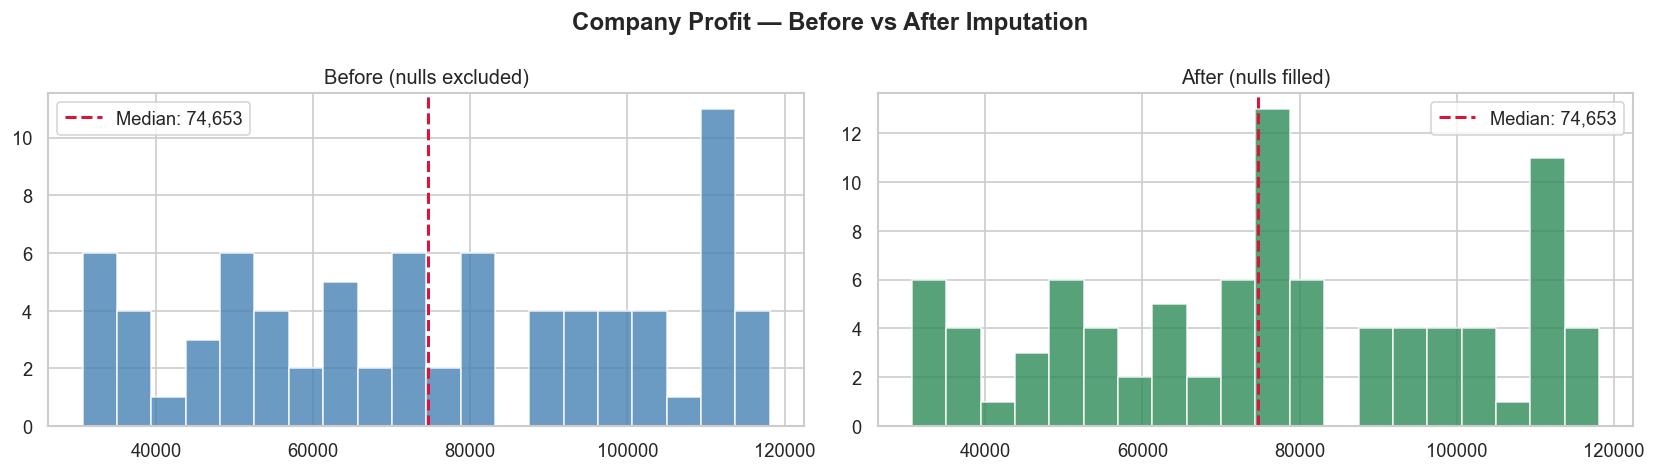

 Null values remaining: 0


In [27]:
## Customers: Impute Missing Company Profit with Median

n_null = cust["Company_Profit"].isna().sum()
median_profit = cust["Company_Profit"].median()
print(f"Null Company_Profit values : {n_null}")
print(f"Imputation value (median)  : PHP {median_profit:,.0f}")

# Store original non-null values for comparison plot
before_vals = cust["Company_Profit"].dropna().copy()

cust["Company_Profit"] = cust["Company_Profit"].fillna(median_profit)

# Visual before / after
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Company Profit — Before vs After Imputation", fontweight="bold")

axes[0].hist(before_vals, bins=20, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(median_profit, color="crimson", ls="--", lw=1.8, label=f"Median: {median_profit:,.0f}")
axes[0].set_title("Before (nulls excluded)")
axes[0].legend()

axes[1].hist(cust["Company_Profit"], bins=20, color="seagreen", edgecolor="white", alpha=0.8)
axes[1].axvline(median_profit, color="crimson", ls="--", lw=1.8, label=f"Median: {median_profit:,.0f}")
axes[1].set_title("After (nulls filled)")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f" Null values remaining: {cust['Company_Profit'].isna().sum()}")

In [31]:
## Products: Infer Missing Product IDs

prod = products.drop_duplicates()

n_null_pid = prod["Product_ID"].isna().sum()
print(f"Null Product_IDs: {n_null_pid}")

expected_ids = set(range(1, 21))
used_ids     = set(prod["Product_ID"].dropna().astype(int))
missing_ids  = sorted(expected_ids - used_ids)
print(f"Missing IDs inferred from sequence: {missing_ids}")

null_idx = prod[prod["Product_ID"].isna()].index
for i, idx in enumerate(null_idx):
    prod.loc[idx, "Product_ID"] = missing_ids[i]

prod["Product_ID"] = prod["Product_ID"].astype(int)

print("Products after ID fix:")
display(prod[["Product_ID", "Product_Name"]].sort_values("Product_ID"))

Null Product_IDs: 2
Missing IDs inferred from sequence: [8, 16]
Products after ID fix:


,Product_ID,Product_Name
0,1,FinPredictor Suite
1,2,MarketMinder Analytics
2,3,TrendWise Forecaster
3,4,CustomerScope Insights
4,5,SalesSync Optimizer
5,6,RevenueVue Dashboard
6,7,DataBridge Integration Tool
7,8,RiskRadar Monitor
8,9,Product 9
9,10,SegmentX Targeting


In [43]:
## Products: Parse Price Strings to Numeric Float

def parse_price(val):
    return float(re.sub(r"[^\d.]", "", str(val)))

print("Before (raw strings):")
print(prod["Product_Price"].tolist())

prod["Product_Price"] = prod["Product_Price"].apply(parse_price)

print("After (numeric float):")
print(prod["Product_Price"].tolist())
print(f" New dtype: {prod['Product_Price'].dtype}")

display(prod[["Product_ID", "Product_Name", "Product_Price"]].sort_values("Product_Price", ascending=False))

Before (raw strings):
['?140,000', '?168,000', '?100,800', '?123,200', '?84,000', '?179,200', '?151,200', '?151,200', '?112,000', '?89,600', '?156,800', '?84,000', '?196,000', '?128,800', '?100,800', '?106,400', '?168,000', '?134,400', '?95,200', '?224,000']
After (numeric float):
[140000.0, 168000.0, 100800.0, 123200.0, 84000.0, 179200.0, 151200.0, 151200.0, 112000.0, 89600.0, 156800.0, 84000.0, 196000.0, 128800.0, 100800.0, 106400.0, 168000.0, 134400.0, 95200.0, 224000.0]
 New dtype: float64


,Product_ID,Product_Name,Product_Price
19,20,FinSphere Intelligence Suite,224000.0
12,13,ForecastXcelerator,196000.0
5,6,RevenueVue Dashboard,179200.0
16,17,RealTime Revenue,168000.0
1,2,MarketMinder Analytics,168000.0
10,11,OptiFlow Automation,156800.0
6,7,DataBridge Integration Tool,151200.0
7,8,RiskRadar Monitor,151200.0
0,1,FinPredictor Suite,140000.0
17,18,DashSync Analytics Hub,134400.0


In [47]:
## Transactions: Drop Redundant Unnamed: 0 Column

trans = transactions.drop_duplicates()

print(f"Columns before: {list(trans.columns)}")
print(f"Is 'Unnamed: 0' just a row index? "
      f"{(trans['Unnamed: 0'].dropna() == trans.index[:len(trans['Unnamed: 0'].dropna())]).all()}")

trans = trans.drop(columns=["Unnamed: 0"])

print(f" Columns after : {list(trans.columns)}")
print(f"Shape         : {trans.shape}")

Columns before: ['Unnamed: 0', 'Transaction_ID', 'Company_ID', 'Product_ID', 'Quantity', 'Transaction_Date', 'Product_Price', 'Total_Cost']
Is 'Unnamed: 0' just a row index? False
 Columns after : ['Transaction_ID', 'Company_ID', 'Product_ID', 'Quantity', 'Transaction_Date', 'Product_Price', 'Total_Cost']
Shape         : (10000, 7)


In [51]:
## Transactions: Impute Missing IDs

for col in ["Transaction_ID", "Company_ID", "Product_ID"]:
    trans[col] = pd.to_numeric(trans[col], errors="coerce")

# Transaction_ID
null_tid = trans["Transaction_ID"].isna().sum()
max_tid  = int(trans["Transaction_ID"].max())
new_ids  = list(range(max_tid + 1, max_tid + 1 + null_tid))
trans.loc[trans["Transaction_ID"].isna(), "Transaction_ID"] = new_ids
trans["Transaction_ID"] = trans["Transaction_ID"].astype(int)
print(f"Transaction_ID: {null_tid} nulls → assigned IDs {max_tid+1} to {max_tid+null_tid}")

# Company_ID
null_coid  = trans["Company_ID"].isna().sum()
mode_coid  = int(trans["Company_ID"].mode()[0])
trans["Company_ID"] = trans["Company_ID"].fillna(mode_coid).astype(int)
print(f"Company_ID    : {null_coid} nulls → filled with mode={mode_coid}")

# Product_ID
null_poid  = trans["Product_ID"].isna().sum()
mode_poid  = int(trans["Product_ID"].mode()[0])
trans["Product_ID"] = trans["Product_ID"].fillna(mode_poid).astype(int)
print(f"Product_ID    : {null_poid} nulls → filled with mode={mode_poid}")

print(f" Null counts after fix:")
print(trans[["Transaction_ID","Company_ID","Product_ID"]].isnull().sum())

Transaction_ID: 1000 nulls → assigned IDs 10000 to 10999
Company_ID    : 1000 nulls → filled with mode=67
Product_ID    : 1000 nulls → filled with mode=6
 Null counts after fix:
Transaction_ID    0
Company_ID        0
Product_ID        0
dtype: int64


In [57]:
## Transactions: Standardise Mixed Date Formats

def parse_date(val):
    for fmt in ("%Y/%m/%d", "%m/%d/%Y", "%m-%d-%Y",
                "%B %d, %Y", "%b %d, %Y", "%d-%m-%Y"):
        try:
            return pd.to_datetime(val, format=fmt)
        except (ValueError, TypeError):
            pass
    return pd.NaT

print("Parsing Transaction_Date …")
trans["Transaction_Date"] = trans["Transaction_Date"].apply(parse_date)

n_nat = trans["Transaction_Date"].isna().sum()
print(f"Unparseable rows (NaT) after custom parser: {n_nat}")

# Drop the few rows that remain unparseable
trans = trans.dropna(subset=["Transaction_Date"])

print(f" Date range  : {trans['Transaction_Date'].min().date()} → {trans['Transaction_Date'].max().date()}")
print(f"dtype       : {trans['Transaction_Date'].dtype}")
print(f"Shape after : {trans.shape}")

# Confirm no mixed-type strings remain
print(f" Sample parsed dates:")
display(trans["Transaction_Date"].sample(6, random_state=1).reset_index(drop=True))

Parsing Transaction_Date …
Unparseable rows (NaT) after custom parser: 0
 Date range  : 2020-01-11 → 2024-12-10
dtype       : datetime64[ns]
Shape after : (10000, 7)
 Sample parsed dates:


0   2022-04-25
1   2022-11-19
2   2022-03-04
3   2024-05-25
4   2023-03-31
5   2022-11-16
Name: Transaction_Date, dtype: datetime64[ns]

Quantity nulls before : 1000
Quantity nulls after  : 0
Global median used as fallback: 11.0


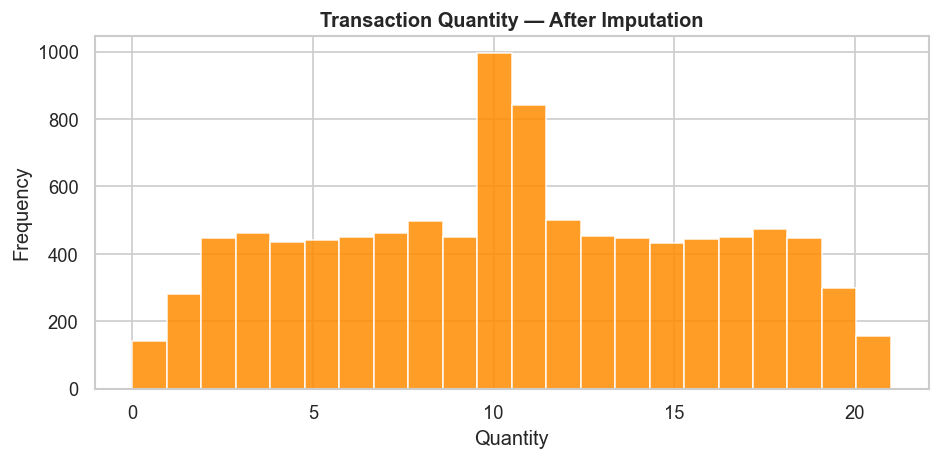

In [59]:
## Transactions: Impute Missing Quantity

trans["Quantity"] = pd.to_numeric(trans["Quantity"], errors="coerce")

null_qty_before = trans["Quantity"].isna().sum()
global_median_qty = trans["Quantity"].median()

# Per-product median imputation
trans["Quantity"] = (trans.groupby("Product_ID")["Quantity"]
                          .transform(lambda x: x.fillna(x.median())))

# Fallback: global median for any remaining nulls
trans["Quantity"] = trans["Quantity"].fillna(global_median_qty).astype(int)

null_qty_after = trans["Quantity"].isna().sum()
print(f"Quantity nulls before : {null_qty_before}")
print(f"Quantity nulls after  : {null_qty_after}")
print(f"Global median used as fallback: {global_median_qty}")

# Distribution after imputation
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(trans["Quantity"], bins=22, color="darkorange", edgecolor="white", alpha=0.85)
ax.set_title("Transaction Quantity — After Imputation", fontweight="bold")
ax.set_xlabel("Quantity")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [61]:
## Transactions: Impute Missing Product Price from Catalogue

price_map = prod.set_index("Product_ID")["Product_Price"].to_dict()
print("Price catalogue (Product_ID → Price):")
for pid, price in sorted(price_map.items()):
    print(f"  Product {pid:>2}: PHP {price:>10,.0f}")

null_pp_before = trans["Product_Price"].isna().sum()

# Apply catalogue lookup
trans["Product_Price"] = trans.apply(
    lambda r: price_map.get(int(r["Product_ID"]), np.nan)
              if pd.isna(r["Product_Price"]) else r["Product_Price"],
    axis=1
)

trans["Product_Price"] = trans["Product_Price"].fillna(trans["Product_Price"].median())

null_pp_after = trans["Product_Price"].isna().sum()
print(f" Product_Price nulls before : {null_pp_before}")
print(f"Product_Price nulls after  : {null_pp_after}")

Price catalogue (Product_ID → Price):
  Product  1: PHP    140,000
  Product  2: PHP    168,000
  Product  3: PHP    100,800
  Product  4: PHP    123,200
  Product  5: PHP     84,000
  Product  6: PHP    179,200
  Product  7: PHP    151,200
  Product  8: PHP    151,200
  Product  9: PHP    112,000
  Product 10: PHP     89,600
  Product 11: PHP    156,800
  Product 12: PHP     84,000
  Product 13: PHP    196,000
  Product 14: PHP    128,800
  Product 15: PHP    100,800
  Product 16: PHP    106,400
  Product 17: PHP    168,000
  Product 18: PHP    134,400
  Product 19: PHP     95,200
  Product 20: PHP    224,000
 Product_Price nulls before : 1000
Product_Price nulls after  : 0


In [63]:
## Transactions: Recompute Missing Total Cost

null_tc_before = trans["Total_Cost"].isna().sum()
print(f"Total_Cost nulls before recomputation: {null_tc_before}")

trans["Total_Cost"] = trans.apply(
    lambda r: r["Quantity"] * r["Product_Price"]
              if pd.isna(r["Total_Cost"]) else r["Total_Cost"],
    axis=1
)

null_tc_after = trans["Total_Cost"].isna().sum()
print(f"Total_Cost nulls after  recomputation: {null_tc_after}")

# Sanity check: compare recomputed vs original on a sample
sample = trans[["Quantity", "Product_Price", "Total_Cost"]].sample(5, random_state=42)
sample["Expected_Cost"] = sample["Quantity"] * sample["Product_Price"]
sample["Match"] = sample["Total_Cost"].round(2) == sample["Expected_Cost"].round(2)
display(sample)

Total_Cost nulls before recomputation: 1000
Total_Cost nulls after  recomputation: 0


,Quantity,Product_Price,Total_Cost,Expected_Cost,Match
6252,11,96097.400362,1.057071e+06,1.057071e+06,True
4684,10,110736.267964,5.040000e+05,1.107363e+06,False
1731,10,122403.914828,7.840000e+05,1.224039e+06,False
4742,5,110477.458370,4.032000e+05,5.523873e+05,False
4521,13,100800.000000,1.209600e+06,1.310400e+06,False


IQR fences : [-1,198,400  –  3,864,000]
Outlier rows (to be winsorised): 104


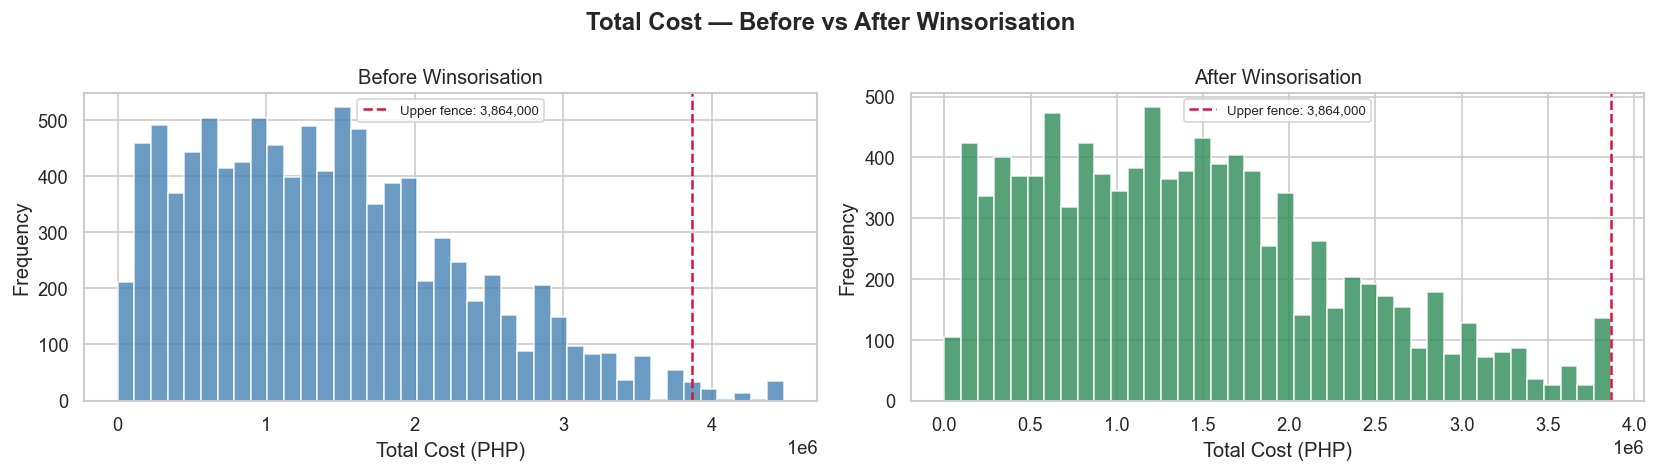

In [65]:
## Transactions: Winsorise Total Cost Outliers

q1, q3  = trans["Total_Cost"].quantile([0.25, 0.75])
iqr_val = q3 - q1
lo_fence = q1 - 1.5 * iqr_val
hi_fence = q3 + 1.5 * iqr_val

n_outliers = ((trans["Total_Cost"] < lo_fence) | (trans["Total_Cost"] > hi_fence)).sum()
print(f"IQR fences : [{lo_fence:,.0f}  –  {hi_fence:,.0f}]")
print(f"Outlier rows (to be winsorised): {n_outliers}")

before_vals = trans["Total_Cost"].copy()
trans["Total_Cost"] = trans["Total_Cost"].clip(lo_fence, hi_fence)

# Before / after plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Total Cost — Before vs After Winsorisation", fontweight="bold")

axes[0].hist(before_vals, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(hi_fence, color="crimson", ls="--", lw=1.5, label=f"Upper fence: {hi_fence:,.0f}")
axes[0].set_title("Before Winsorisation")
axes[0].legend(fontsize=8)

axes[1].hist(trans["Total_Cost"], bins=40, color="seagreen", edgecolor="white", alpha=0.8)
axes[1].axvline(hi_fence, color="crimson", ls="--", lw=1.5, label=f"Upper fence: {hi_fence:,.0f}")
axes[1].set_title("After Winsorisation")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel("Total Cost (PHP)")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [67]:
## Final Null Check & Data Type Validation

print("═" * 55)
print("  FINAL NULL CHECK")
print("═" * 55)
for name, df in [("customers_clean", cust),
                 ("products_clean",  prod),
                 ("transactions_clean", trans)]:
    total_null = df.isnull().sum().sum()
    status     = "✓ PASS" if total_null == 0 else f"✗ FAIL — {total_null} nulls remain"
    print(f"  {name:<25}: {status}")
    if total_null > 0:
        display(df.isnull().sum()[df.isnull().sum() > 0])

print()
print("═" * 55)
print("  DATA TYPE VALIDATION")
print("═" * 55)

print(" ── customers_clean ──")
display(cust.dtypes.to_frame("dtype"))

print(" ── products_clean ──")
display(prod.dtypes.to_frame("dtype"))

print(" ── transactions_clean ──")
display(trans.dtypes.to_frame("dtype"))

print()
print("═" * 55)
print("  SHAPE SUMMARY")
print("═" * 55)
print(f"  customers_clean    : {cust.shape}")
print(f"  products_clean     : {prod.shape}")
print(f"  transactions_clean : {trans.shape}")

═══════════════════════════════════════════════════════
  FINAL NULL CHECK
═══════════════════════════════════════════════════════
  customers_clean          : ✓ PASS
  products_clean           : ✓ PASS
  transactions_clean       : ✓ PASS

═══════════════════════════════════════════════════════
  DATA TYPE VALIDATION
═══════════════════════════════════════════════════════
 ── customers_clean ──


,dtype
Company_ID,int64
Company_Name,object
Company_Profit,float64
Address,object


 ── products_clean ──


,dtype
Product_ID,int64
Product_Name,object
Product_Price,float64


 ── transactions_clean ──


,dtype
Transaction_ID,int64
Company_ID,int64
Product_ID,int64
Quantity,int64
Transaction_Date,datetime64[ns]
Product_Price,float64
Total_Cost,float64



═══════════════════════════════════════════════════════
  SHAPE SUMMARY
═══════════════════════════════════════════════════════
  customers_clean    : (90, 4)
  products_clean     : (20, 3)
  transactions_clean : (10000, 7)


In [69]:
## Save Cleaned Datasets

OUTPUT_DIR = "/Users/jemwagas/Week-2-Homework"
os.makedirs(OUTPUT_DIR, exist_ok=True)

out_paths = {
    "customers_clean.csv"    : cust,
    "products_clean.csv"     : prod,
    "transactions_clean.csv" : trans,
}

for filename, df in out_paths.items():
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    size_kb = os.path.getsize(path) / 1024
    print(f"  ✓ {filename:<30} ({df.shape[0]:,} rows × {df.shape[1]} cols  |  {size_kb:.1f} KB)")

  ✓ customers_clean.csv            (90 rows × 4 cols  |  7.1 KB)
  ✓ products_clean.csv             (20 rows × 3 cols  |  0.7 KB)
  ✓ transactions_clean.csv         (10,000 rows × 7 cols  |  507.1 KB)


In [ ]:
⚙️ Part B — Feature Engineering

Date features added:


,Transaction_Date,Year,Month,Quarter,DayOfWeek,IsWeekend,DayOfYear
0,2024-03-26,2024,3,1,1,0,86
1,2024-07-09,2024,7,3,1,0,191
2,2024-04-13,2024,4,2,5,1,104
3,2023-09-06,2023,9,3,2,0,249
4,2021-07-06,2021,7,3,1,0,187
5,2021-07-12,2021,7,3,0,0,193


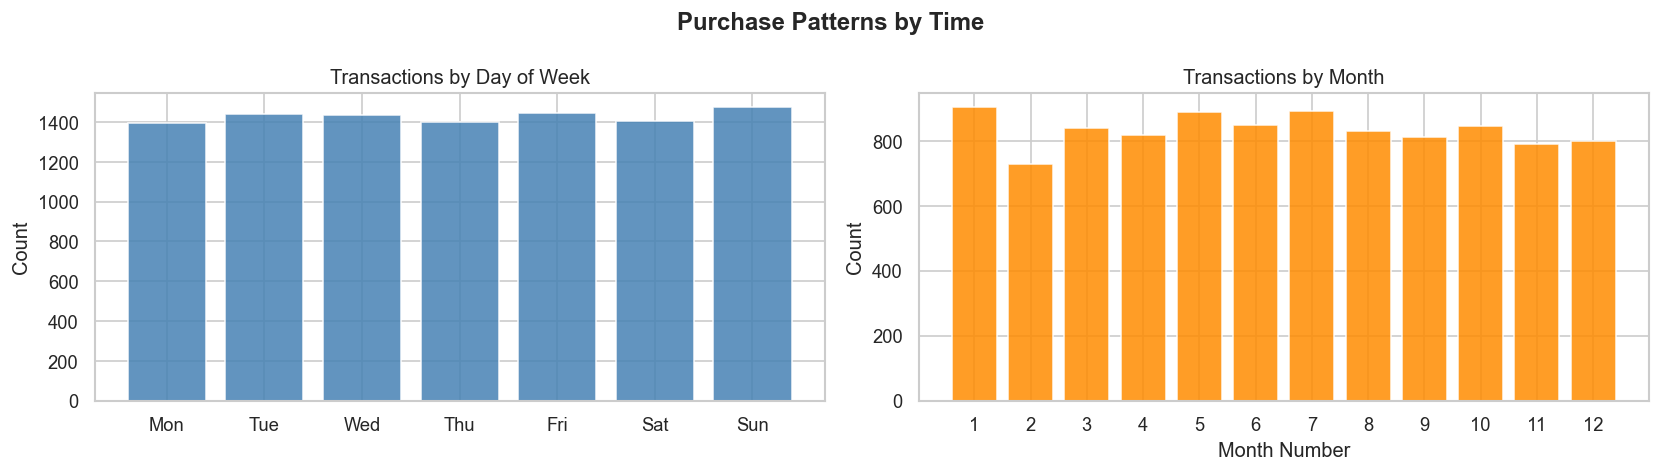

In [71]:
## Date Features

feat = trans.copy()

feat["Year"]      = feat["Transaction_Date"].dt.year
feat["Month"]     = feat["Transaction_Date"].dt.month
feat["Quarter"]   = feat["Transaction_Date"].dt.quarter
feat["DayOfWeek"] = feat["Transaction_Date"].dt.dayofweek   # 0 = Monday, 6 = Sunday
feat["IsWeekend"] = (feat["DayOfWeek"] >= 5).astype(int)
feat["DayOfYear"] = feat["Transaction_Date"].dt.dayofyear

print("Date features added:")
display(feat[["Transaction_Date","Year","Month","Quarter",
              "DayOfWeek","IsWeekend","DayOfYear"]].head(6))

# Quick view of purchase distribution by day of week
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Purchase Patterns by Time", fontweight="bold")

day_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_counts = feat["DayOfWeek"].value_counts().sort_index()
axes[0].bar(day_labels, dow_counts.values, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_title("Transactions by Day of Week")
axes[0].set_ylabel("Count")

month_counts = feat["Month"].value_counts().sort_index()
axes[1].bar([str(m) for m in month_counts.index], month_counts.values,
            color="darkorange", edgecolor="white", alpha=0.85)
axes[1].set_title("Transactions by Month")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Month Number")

plt.tight_layout()
plt.show()

Reference date for Recency calculation: 2024-12-11
 RFM table shape: (100, 8)


,Company_ID,Recency,Frequency,Monetary,AvgSpend,AvgQty,TotalQty,UniqueProds
count,100.00,100.00,100.00,1.000000e+02,100.00,100.00,100.00,100.00
mean,50.50,49.97,100.00,1.417669e+08,1416113.53,10.51,1052.41,19.60
std,29.01,21.28,103.69,1.476458e+08,84952.81,0.53,1101.49,0.62
min,1.00,1.00,68.00,8.715443e+07,1216524.97,9.05,695.00,18.00
25%,25.75,40.00,84.00,1.173745e+08,1363154.93,10.17,880.00,19.00
50%,50.50,49.50,90.00,1.271825e+08,1408088.54,10.56,936.00,20.00
75%,75.25,63.00,95.25,1.354387e+08,1479600.53,10.89,1013.50,20.00
max,100.00,108.00,1123.00,1.595702e+09,1585099.10,11.68,11906.00,20.00


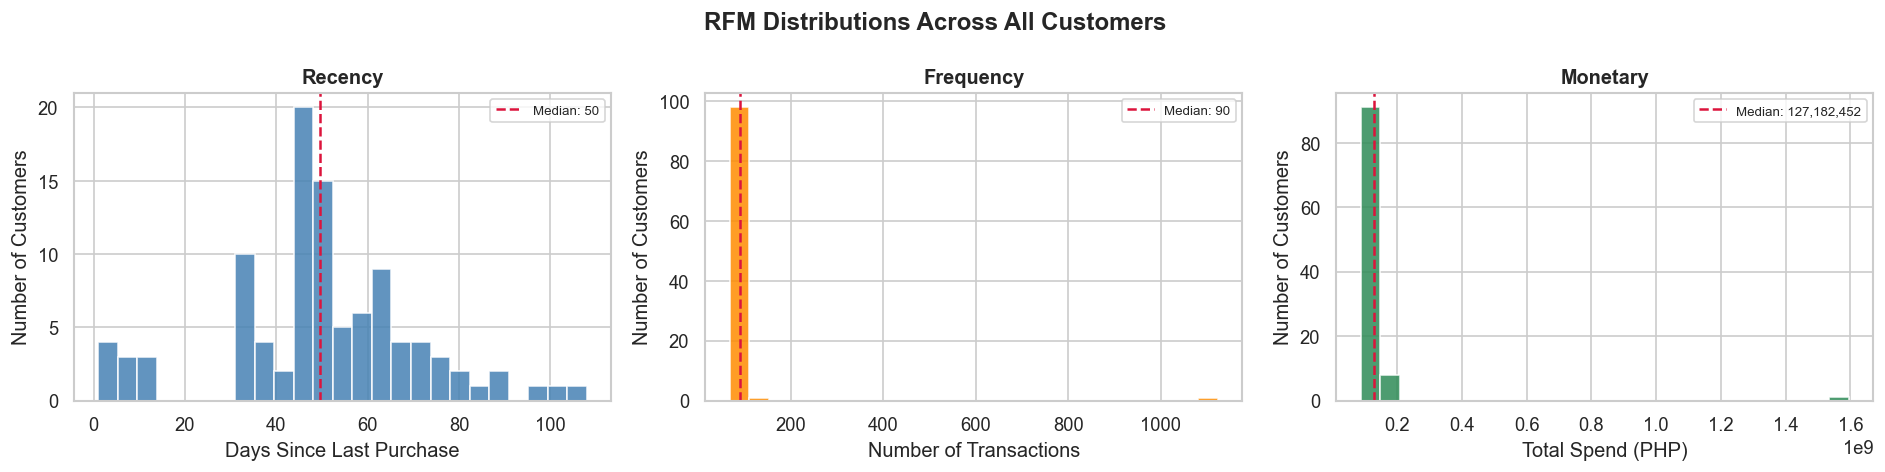

In [75]:
## RFM Features (Recency, Frequency, Monetary)
ref_date = feat["Transaction_Date"].max() + pd.Timedelta(days=1)
print(f"Reference date for Recency calculation: {ref_date.date()}")

rfm = feat.groupby("Company_ID").agg(
    Recency     = ("Transaction_Date", lambda x: (ref_date - x.max()).days),
    Frequency   = ("Transaction_ID",   "count"),
    Monetary    = ("Total_Cost",       "sum"),
    AvgSpend    = ("Total_Cost",       "mean"),
    AvgQty      = ("Quantity",         "mean"),
    TotalQty    = ("Quantity",         "sum"),
    UniqueProds = ("Product_ID",       "nunique"),
).reset_index()

print(f" RFM table shape: {rfm.shape}")
display(rfm.describe().round(2))

# Visualise the three core RFM dimensions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("RFM Distributions Across All Customers", fontweight="bold")

for ax, col, color, label in zip(
        axes,
        ["Recency", "Frequency", "Monetary"],
        ["steelblue", "darkorange", "seagreen"],
        ["Days Since Last Purchase", "Number of Transactions", "Total Spend (PHP)"]):
    ax.hist(rfm[col], bins=25, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(rfm[col].median(), color="crimson", ls="--", lw=1.5,
               label=f"Median: {rfm[col].median():,.0f}")
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("Number of Customers")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [79]:
## Product-Level Features & Price Category

prod_feats = feat.groupby("Product_ID").agg(
    ProdTotalRevenue = ("Total_Cost",      "sum"),
    ProdAvgQty       = ("Quantity",        "mean"),
    ProdTxCount      = ("Transaction_ID",  "count"),
).reset_index()

print("Product-level features:")
display(prod_feats)

# Price category bucketing on the products table
price_bins   = [0, 100_000, 150_000, 200_000, 999_999]
price_labels = ["Budget", "Mid", "Premium", "Luxury"]
prod["PriceCategory"] = pd.cut(prod["Product_Price"],
                                bins=price_bins, labels=price_labels)

print("Price category distribution:")
display(prod[["Product_Name","Product_Price","PriceCategory"]].sort_values("Product_Price"))

Product-level features:


,Product_ID,ProdTotalRevenue,ProdAvgQty,ProdTxCount
0,1,6.386163e+08,9.922907,454
1,2,8.000852e+08,10.186695,466
2,3,4.640772e+08,10.015217,460
3,4,5.622706e+08,10.748826,426
4,5,3.932182e+08,10.325893,448
5,6,2.358814e+09,10.382724,1505
6,7,6.755950e+08,10.512761,431
7,8,6.939463e+08,10.442177,441
8,9,5.251984e+08,10.453725,443
9,10,4.315104e+08,10.519565,460


Price category distribution:


,Product_Name,Product_Price,PriceCategory
4,SalesSync Optimizer,84000.0,Budget
11,BudgetMaster Pro,84000.0,Budget
9,SegmentX Targeting,89600.0,Budget
18,EcoNomix Modeler,95200.0,Budget
2,TrendWise Forecaster,100800.0,Mid
14,NexGen Segmentator,100800.0,Mid
15,SpendTrack Plus,106400.0,Mid
8,Product 9,112000.0,Mid
3,CustomerScope Insights,123200.0,Mid
13,InsightMax Insights Platform,128800.0,Mid


In [81]:
## Merge All Features into One Master Table

master = feat.merge(rfm, on="Company_ID", how="left")

master = master.merge(prod_feats, on="Product_ID", how="left")

master = master.merge(
    prod[["Product_ID","Product_Name","Product_Price","PriceCategory"]],
    on="Product_ID", how="left", suffixes=("","_prod"))

master = master.merge(
    cust[["Company_ID","Company_Name","Company_Profit"]],
    on="Company_ID", how="left", suffixes=("","_cust"))

print(f"Master table shape: {master.shape}")
print(f"Columns ({len(master.columns)} total):")
for col in master.columns:
    print(f"  {col}")

Master table shape: (10000, 28)
Columns (28 total):
  Transaction_ID
  Company_ID
  Product_ID
  Quantity
  Transaction_Date
  Product_Price
  Total_Cost
  Year
  Month
  Quarter
  DayOfWeek
  IsWeekend
  DayOfYear
  Recency
  Frequency
  Monetary
  AvgSpend
  AvgQty
  TotalQty
  UniqueProds
  ProdTotalRevenue
  ProdAvgQty
  ProdTxCount
  Product_Name
  Product_Price_prod
  PriceCategory
  Company_Name
  Company_Profit


In [83]:
## Interaction Features

master["SpendVsProfit"]      = master["Total_Cost"] / (master["Company_Profit"] + 1)
master["AvgSpendPerProduct"] = master["Monetary"]   / (master["UniqueProds"]    + 1)
master["FreqPerMonth"]       = master["Frequency"]  / (master["Month"]          + 1)

print("Interaction features added. Sample values:")
display(master[["Company_ID","SpendVsProfit",
                "AvgSpendPerProduct","FreqPerMonth"]].head(6).round(4))

Interaction features added. Sample values:


,Company_ID,SpendVsProfit,AvgSpendPerProduct,FreqPerMonth
0,88,14.1565,6.212620e+06,21.750
1,29,23.0497,5.997595e+06,9.875
2,28,NaN,6.462406e+06,16.800
3,85,8.8833,6.048442e+06,9.300
4,47,22.6655,4.357721e+06,8.500
5,80,5.6389,7.472610e+06,12.375


PriceCategory label encoding mapping:
  Budget → 0
  Luxury → 1
  Mid → 2
  Premium → 3
Month dummy columns added: ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']
Target variable 'HighValueCustomer':
  Threshold (median Monetary) : PHP 131,007,049
  High-value transactions     : 50.9%
  Low-value  transactions     : 49.1%


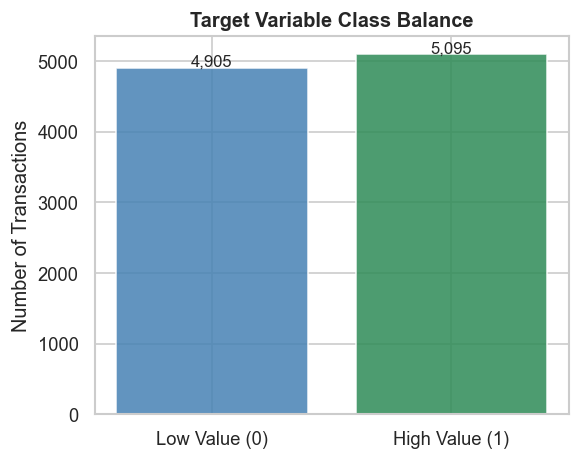

In [95]:
## Encode Categories & Define the Target Variable

# ── Label encode PriceCategory ──
le = LabelEncoder()
master["PriceCategory_Enc"] = le.fit_transform(master["PriceCategory"].astype(str))
print("PriceCategory label encoding mapping:")
for label, code_val in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {label} → {code_val}")

# ── One-hot encode Month (seasonality) ──
month_dummies = pd.get_dummies(master["Month"], prefix="Month")
master        = pd.concat([master, month_dummies], axis=1)
print(f"Month dummy columns added: {[c for c in master.columns if c.startswith('Month_')]}")

# ── Define target variable ──
median_monetary = master["Monetary"].median()
master["HighValueCustomer"] = (master["Monetary"] >= median_monetary).astype(int)

pct_high = master["HighValueCustomer"].mean() * 100
print(f"Target variable 'HighValueCustomer':")
print(f"  Threshold (median Monetary) : PHP {median_monetary:,.0f}")
print(f"  High-value transactions     : {pct_high:.1f}%")
print(f"  Low-value  transactions     : {100 - pct_high:.1f}%")

# Class balance bar chart
fig, ax = plt.subplots(figsize=(5, 4))
counts = master["HighValueCustomer"].value_counts().sort_index()
ax.bar(["Low Value (0)", "High Value (1)"], counts.values,
       color=["steelblue","seagreen"], edgecolor="white", alpha=0.85)
ax.set_title("Target Variable Class Balance", fontweight="bold")
ax.set_ylabel("Number of Transactions")
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f"{v:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

Scaled columns added: 10
Sample scaled values (should be centred around 0):


,Recency_Scaled,Recency_Scaled,Frequency_Scaled,Frequency_Scaled,Monetary_Scaled,Monetary_Scaled,AvgSpend_Scaled,AvgSpend_Scaled,TotalQty_Scaled,TotalQty_Scaled,UniqueProds_Scaled,UniqueProds_Scaled,Company_Profit_Scaled,Company_Profit_Scaled,SpendVsProfit_Scaled,SpendVsProfit_Scaled,AvgSpendPerProduct_Scaled,AvgSpendPerProduct_Scaled,FreqPerMonth_Scaled,FreqPerMonth_Scaled
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,9121.000,9121.000,9121.000,9121.000,10000.000,10000.000,10000.000,10000.000
mean,-0.000,-0.000,-0.000,-0.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-2.273,-2.273,-0.425,-0.425,-0.444,-0.444,-2.523,-2.523,-0.430,-0.430,-2.843,-2.843,-1.920,-1.920,-1.267,-1.267,-0.440,-0.440,-0.425,-0.425
25%,-0.685,-0.685,-0.369,-0.369,-0.375,-0.375,-0.583,-0.583,-0.374,-0.374,-1.130,-1.130,-0.603,-0.603,-0.715,-0.715,-0.373,-0.373,-0.376,-0.376
50%,-0.011,-0.011,-0.351,-0.351,-0.350,-0.350,0.041,0.041,-0.351,-0.351,0.583,0.583,-0.068,-0.068,-0.211,-0.211,-0.348,-0.348,-0.318,-0.318
75%,0.615,0.615,-0.333,-0.333,-0.328,-0.328,0.681,0.681,-0.326,-0.326,0.583,0.583,0.776,0.776,0.431,0.431,-0.326,-0.326,-0.141,-0.141
max,2.877,2.877,2.811,2.811,2.810,2.810,2.100,2.100,2.810,2.810,0.583,0.583,1.762,1.762,6.321,6.321,2.810,2.810,6.815,6.815


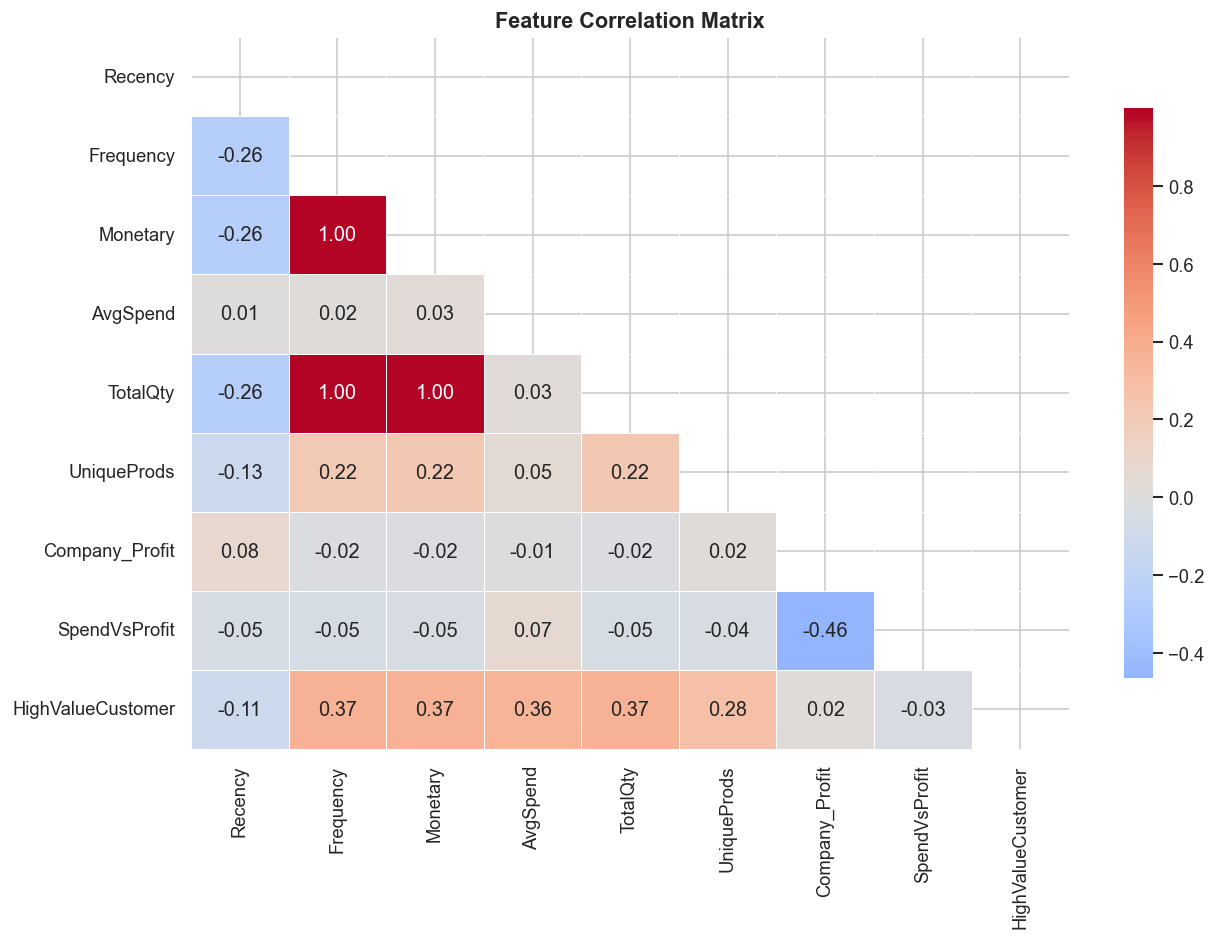

In [101]:
## Scale Numeric Features & Correlation Heatmap

scale_cols = ["Recency","Frequency","Monetary","AvgSpend","TotalQty",
              "UniqueProds","Company_Profit","SpendVsProfit",
              "AvgSpendPerProduct","FreqPerMonth"]
scale_cols = [c for c in scale_cols if c in master.columns]

scaler = StandardScaler()
scaled_array = scaler.fit_transform(master[scale_cols])
scaled_df    = pd.DataFrame(scaled_array,
                             columns=[f"{c}_Scaled" for c in scale_cols],
                             index=master.index)
master = pd.concat([master, scaled_df], axis=1)

print(f"Scaled columns added: {len(scale_cols)}")
print("Sample scaled values (should be centred around 0):")
display(master[[f"{c}_Scaled" for c in scale_cols]].describe().round(3))

# Correlation heatmap on key features
heatmap_cols = ["Recency","Frequency","Monetary","AvgSpend","TotalQty",
                "UniqueProds","Company_Profit","SpendVsProfit","HighValueCustomer"]
heatmap_cols = [c for c in heatmap_cols if c in master.columns]
corr = master[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.4,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [99]:
## Save Outputs

outputs = {
    "features_engineered.csv" : master,
}

for filename, df in outputs.items():
    path    = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    size_kb = os.path.getsize(path) / 1024
    print(f"  ✓ {filename:<30} {df.shape[0]:>6,} rows × {df.shape[1]:>3} cols  |  {size_kb:>7.1f} KB")

  ✓ features_engineered.csv        10,000 rows ×  55 cols  |   5435.2 KB
